# Training log curves

Plot loss and KPI series from `training_log.json` for a run under `introducing_superpoint/runs/`.

In [25]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent.parent))
sys.path.append(str(Path.cwd().parent))

import conf
from model_instance import ModelInstance, TrainingConfig

In [26]:
RUN_NAME   = "oyster"
RUNS_SOURCE = "git_saved_runs"   # "runs" | "git_saved_runs"

_REPO_ROOT = Path.cwd().parent.parent

if RUNS_SOURCE == "git_saved_runs":
    log_path = _REPO_ROOT / "introducing_superpoint" / "git_saved_runs" / "training_log.json"
else:
    log_path = ModelInstance(name=RUN_NAME, config=TrainingConfig(name=RUN_NAME)).log_path

instance = ModelInstance.load_log(log_path)
print(log_path)
print(f"epochs: {len(instance.epoch_logs)}")

/Users/alexanderhallmann/Desktop/medical-image-registration/introducing_superpoint/git_saved_runs/training_log.json
epochs: 1


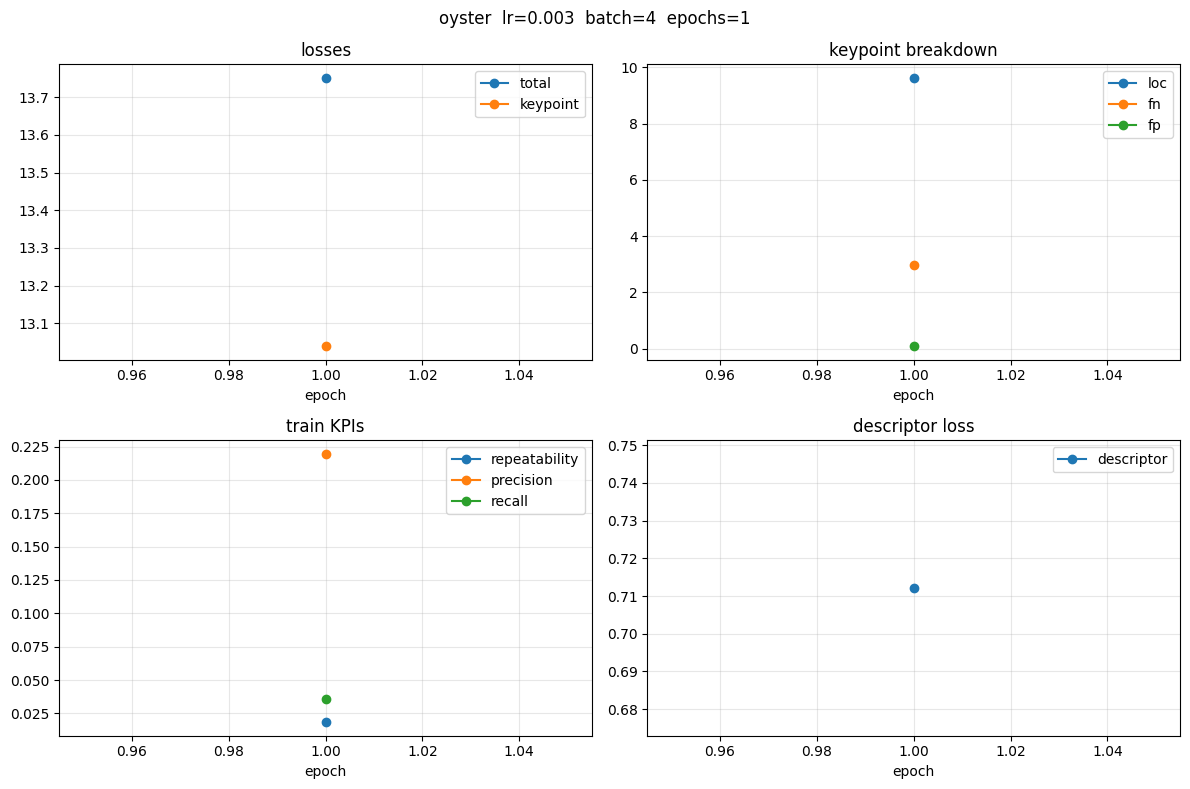

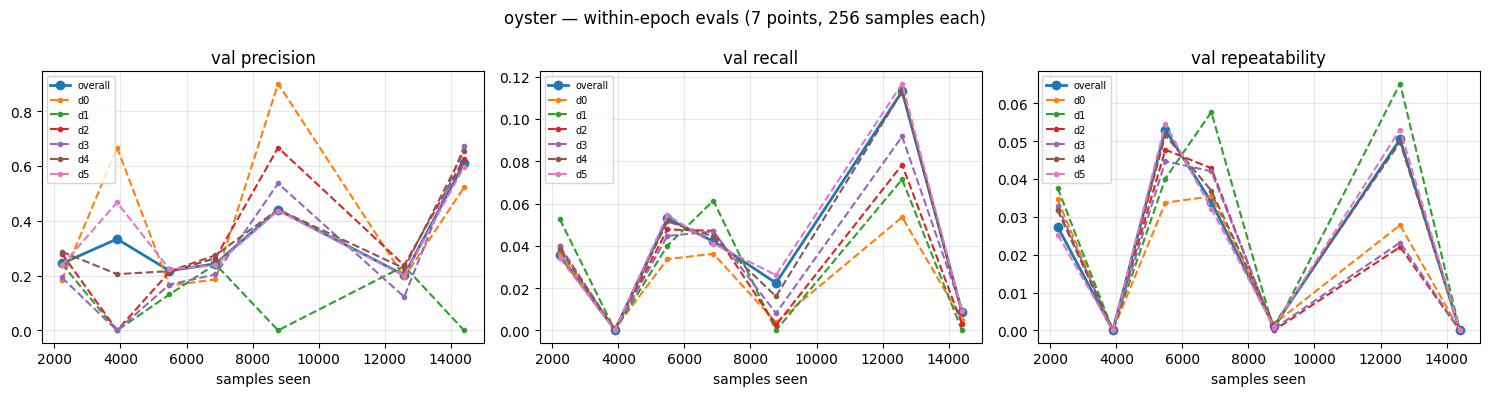

In [27]:
logs      = instance.epoch_logs
eval_logs = instance.evaluation_logs
cfg       = instance.config

has_epoch_data = bool(logs)
has_eval_data  = bool(eval_logs)

# ── Epoch-level plots ──────────────────────────────────────────────────────
if has_epoch_data:
    epochs = [e.epoch for e in logs]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    panels = [
        (axes[0, 0], "losses",            [("total", "loss_total"), ("keypoint", "loss_keypoint")]),
        (axes[0, 1], "keypoint breakdown",[("loc", "loss_loc"), ("fn", "loss_fn"), ("fp", "loss_fp")]),
        (axes[1, 0], "train KPIs",        [("repeatability", "repeatability"), ("precision", "precision"), ("recall", "recall")]),
        (axes[1, 1], "descriptor loss",   [("descriptor", "loss_descriptor")]),
    ]
    for ax, title, fields in panels:
        for label, field in fields:
            ax.plot(epochs, [getattr(e, field) for e in logs], label=label, marker="o")
        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"{instance.name}  lr={cfg.learning_rate}  batch={cfg.batch_size}  epochs={len(logs)}")
    fig.tight_layout()
    plt.show()

# ── Intra-epoch eval plots (evaluation_logs) ───────────────────────────────
if has_eval_data:
    eval_logs_sorted = sorted(eval_logs, key=lambda e: e.samples_seen)
    xs        = [e.samples_seen for e in eval_logs_sorted]
    depth_keys = sorted({k for e in eval_logs_sorted for k in (e.kpis_by_depth or {})})

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, metric in zip(axes, ["precision", "recall", "repeatability"]):
        ax.plot(xs, [getattr(e, metric) for e in eval_logs_sorted],
                label="overall", linewidth=2, marker="o")
        for dk in depth_keys:
            vals = [(e.kpis_by_depth or {}).get(dk, {}).get(metric) for e in eval_logs_sorted]
            if any(v is not None for v in vals):
                ax.plot(xs, [v or 0 for v in vals], label=dk, linestyle="--", marker=".")
        ax.set_title(f"val {metric}")
        ax.set_xlabel("samples seen")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"{instance.name} — within-epoch evals ({len(eval_logs_sorted)} points, {eval_logs_sorted[0].num_samples} samples each)")
    fig.tight_layout()
    plt.show()

if not has_epoch_data and not has_eval_data:
    print("no logs to plot")